# Energy Consumption Prediction using XGBoost

## Project Overview
This project aims to predict the energy consumption of buildings based on various structural and environmental features (e.g., building size, outside temperature, solar radiation).

**Objective:** Build a robust regression model to accurately forecast energy use, enabling better energy management and efficiency.

**Methodology:**
1. Exploratory Data Analysis (EDA)
2. Baseline Model Generation
3. Advanced Modeling with XGBoost
4. Model Evaluation & Feature Importance Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style="whitegrid")
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


## 1. Data Loading and Inspection

In [2]:
df = pd.read_csv('energy_consumption_prediction.csv')
display(df.head())
display(df.info())
display(df.describe())

,building_size,num_occupants,num_appliances,outside_temp,inside_temp,humidity,hour_of_day,day_of_week,is_weekend,solar_radiation,wind_speed,insulation_quality,energy_consumption
0,218.543053,20,34,10.118400,16.748231,76.732400,16,3,0,421.441447,18.009614,1.135626,329.541273
1,477.821438,39,8,-8.931946,29.886419,82.655129,21,6,1,386.235564,17.850043,1.064549,697.615641
2,379.397274,3,17,20.507152,21.936702,53.757046,0,2,0,949.145007,2.739965,0.706921,182.672731
3,319.396318,5,11,11.157176,28.983132,59.486001,15,1,0,386.781356,8.788459,1.365705,242.720456
4,120.208388,1,42,35.988232,26.139800,73.941266,8,2,0,78.477837,10.317220,0.710920,74.599593


<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   building_size       12000 non-null  float64
 1   num_occupants       12000 non-null  int64  
 2   num_appliances      12000 non-null  int64  
 3   outside_temp        12000 non-null  float64
 4   inside_temp         12000 non-null  float64
 5   humidity            12000 non-null  float64
 6   hour_of_day         12000 non-null  int64  
 7   day_of_week         12000 non-null  int64  
 8   is_weekend          12000 non-null  int64  
 9   solar_radiation     12000 non-null  float64
 10  wind_speed          12000 non-null  float64
 11  insulation_quality  12000 non-null  float64
 12  energy_consumption  12000 non-null  float64
dtypes: float64(8), int64(5)
memory usage: 1.2 MB


None

,building_size,num_occupants,num_appliances,outside_temp,inside_temp,humidity,hour_of_day,day_of_week,is_weekend,solar_radiation,wind_speed,insulation_quality,energy_consumption
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,273.220207,24.975333,27.093250,14.916284,22.976451,55.062486,11.482250,2.985167,0.287667,499.320109,9.937983,1.001377,302.729756
std,129.717114,14.206772,12.920583,14.416455,4.046613,20.181999,6.948048,2.010709,0.452694,290.627618,5.761653,0.289470,179.234909
min,50.005236,1.000000,5.000000,-9.999723,16.000234,20.000590,0.000000,0.000000,0.000000,0.128825,0.000587,0.500028,-323.058724
25%,161.120809,13.000000,16.000000,2.392868,19.443818,37.882751,5.000000,1.000000,0.000000,244.591971,4.904865,0.748767,177.408248
50%,272.262694,25.000000,27.000000,14.943124,22.963667,54.978409,11.000000,3.000000,0.000000,500.788730,10.021270,1.001156,302.339948
75%,385.017146,37.000000,38.000000,27.337593,26.503229,72.673278,18.000000,5.000000,1.000000,755.327494,14.868879,1.255325,429.263013
max,499.872953,49.000000,49.000000,39.989469,29.999610,89.995779,23.000000,6.000000,1.000000,999.992042,19.999519,1.499775,945.220295


## 2. Exploratory Data Analysis (EDA)
Before modeling, we must understand the data distributions and correlations. This helps identify highly predictive features and potential multicollinearity.

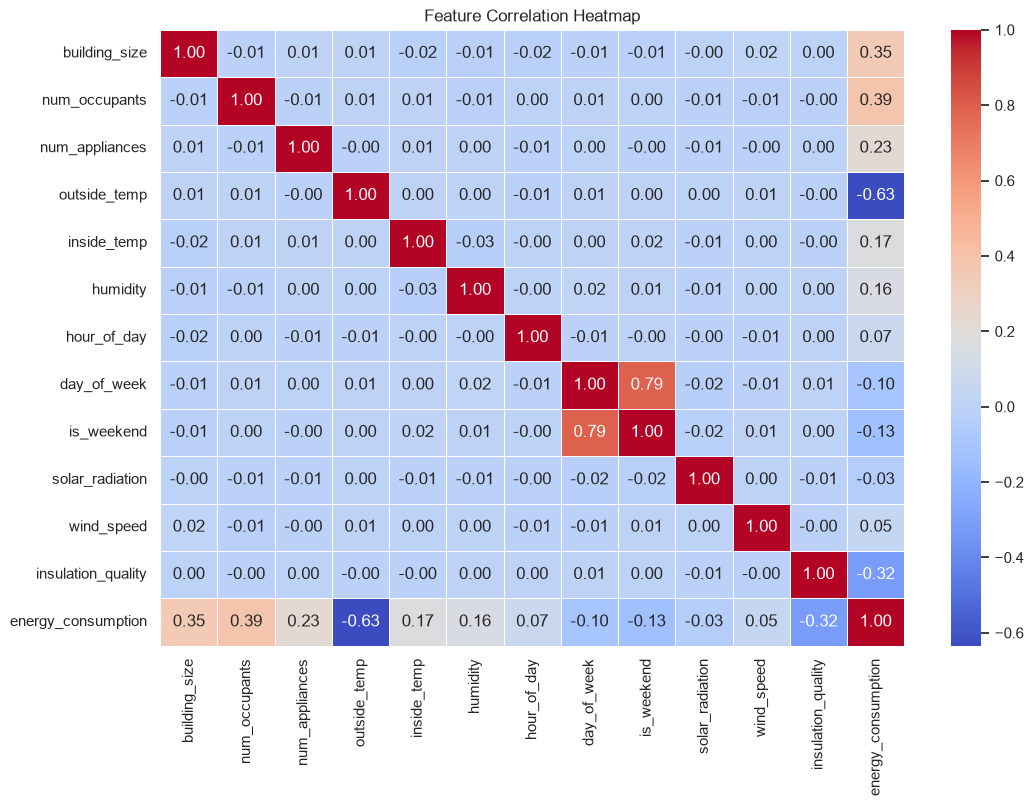

In [3]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

## 3. Data Splitting & Baseline Model
A baseline model gives us a reference point. If our XGBoost model cannot significantly outperform a naive approach (such as simply predicting the mean energy consumption every time), the complex model isn't adding value.

In [4]:
# Separate features and target
X = df.drop(columns=['energy_consumption'])
y = df['energy_consumption']

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline Model: Always predicts the mean of the training target
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

print(f"Baseline RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_base)):.2f}")
print(f"Baseline R2: {r2_score(y_test, y_pred_base):.4f}")

Baseline RMSE: 178.03
Baseline R2: -0.0001


## 4. XGBoost Model Training
We use XGBoost, a powerful gradient boosting algorithm. Note that decision-tree based methods like XGBoost do not strictly require feature scaling, simplifying our pipeline.

In [5]:
# Initialize and train the XGBoost Regressor inside a Pipeline
xgb_model = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("--- XGBoost Performance ---")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE:  {mae_xgb:.2f}")
print(f"R2 Score: {r2_xgb:.4f}")


--- XGBoost Performance ---
RMSE: 54.22
MAE:  43.54
R2 Score: 0.9072


## 5. Model Evaluation
Comparing the XGBoost predictions against our test set and the naive baseline.

In [6]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("--- XGBoost Performance ---")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE:  {mae_xgb:.2f}")
print(f"R2 Score: {r2_xgb:.4f}")

--- XGBoost Performance ---
RMSE: 54.22
MAE:  43.54
R2 Score: 0.9072


## 6. Feature Importance
Understanding which factors drive energy consumption the most provides actionable business insights.

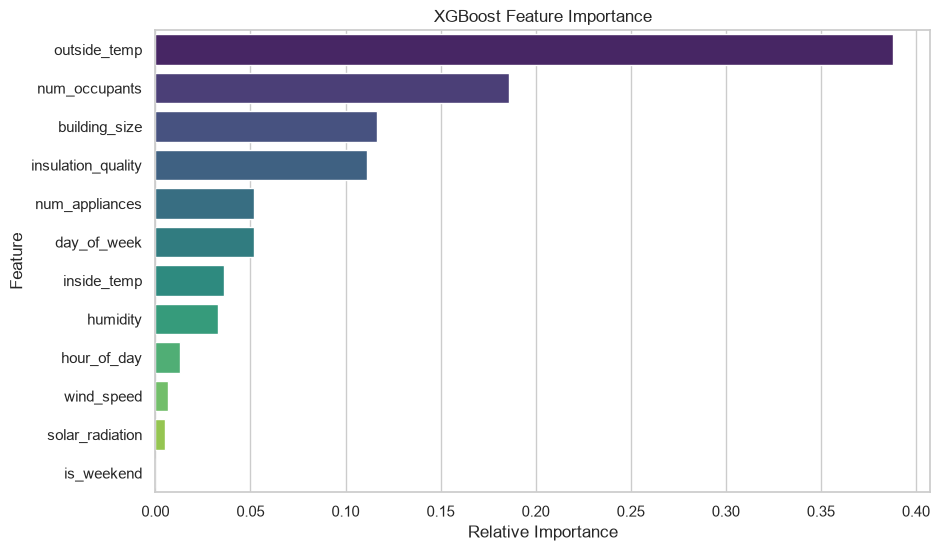

In [7]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.named_steps['xgb'].feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('XGBoost Feature Importance')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.show()

## 7. Save Model
Export the trained model for future inference.

In [8]:
joblib.dump(xgb_model, 'xgboost_energy_model.pkl')
print("Model saved successfully as 'xgboost_energy_model.pkl'")

Model saved successfully as 'xgboost_energy_model.pkl'
